In [1]:
%pip install pingouin normflows optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.6 MB/s eta 0:00:00
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size=87247 sha256=b5a404930c86781e27c861d461e27196ab21f37981faee2edb3fe4a6b74910a4
  Stored in directory: /root/.cache/pip/wheels/f7/b4/37/a3acc21799a058d6fe15127321dcdf99826f438bb591accafa
Successfully built normflows


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

import shap
import optuna

from joblib import Parallel, delayed
from tqdm import tqdm, trange

from scipy import stats
from sklearn.preprocessing import StandardScaler

from iom import InfluentialOutlierMetric

## Simulate data

In [5]:
def simulate_outliers_bimodal(
    n_schools=100,
    students_per_school=30,
    n_school_outliers=5,
    n_student_outliers=3,
    seed=123
):
    """
    Simulate hierarchical school/student data with bimodal residuals and injected outliers.

    Parameters
    ----------
    n_schools : int, default=100
        Number of schools.
    students_per_school : int, default=30
        Number of students per school.
    n_school_outliers : int, default=5
        Number of schools with outlier random effects.
    n_student_outliers : int, default=3
        Number of student-level outliers in normal schools.
    seed : int, default=123
        Random seed for reproducibility.

    Returns
    -------
    df : pd.DataFrame
        Simulated student-level data with predictors, outcome, and outlier flags.
    school_outliers : np.ndarray
        Indices of outlier schools.
    student_outliers : np.ndarray
        Indices of outlier students.
    school_re_df : pd.DataFrame
        School-level random effect table with outlier flags.
    """
    np.random.seed(seed)
    N = n_schools * students_per_school
    school_ids = np.repeat(np.arange(n_schools), students_per_school)
    student_ids = np.arange(N)

    # Predictors
    x = np.random.normal(0, 1, N)
    ses_school = np.random.normal(0, 1, n_schools)
    ses = ses_school[school_ids]

    # Base random intercepts
    school_re = np.random.normal(0, 1, n_schools)

    # Create outlier schools with specified random effects
    school_outliers = np.random.choice(n_schools, n_school_outliers, replace=False)
    re_values = np.array([2, 4, 6, 8, 10])
    for s, val in zip(school_outliers, re_values):
        school_re[s] = val

    re = school_re[school_ids]

    # SES shift for outlier schools
    outlier_mask = np.isin(school_ids, school_outliers)
    ses[outlier_mask] = 4

    # Bimodal residual mixture
    mix_components = np.random.choice([0, 1], size=N, p=[0.6, 0.4])
    residuals = np.zeros(N)
    n0 = np.sum(mix_components == 0)
    n1 = N - n0
    residuals[mix_components == 0] = np.random.normal(3, 1, size=n0)
    residuals[mix_components == 1] = np.random.normal(-3, 1, size=n1)
    residuals = residuals - np.mean(residuals)

    # Outcome
    y = 2 + 1.5 * x + 0.75 * ses + re + residuals

    df = pd.DataFrame({
        "student": student_ids,
        "school": school_ids,
        "x": x,
        "ses": ses,
        "y": y
    })

    df["school_outlier"] = df["school"].isin(school_outliers).astype(int)

    # Student-level outliers in normal schools
    normal_schools = [s for s in range(n_schools) if s not in school_outliers]
    normal_student_indices = df[df["school"].isin(normal_schools)].index
    student_outliers = np.random.choice(normal_student_indices, n_student_outliers, replace=False)

    df.loc[student_outliers, "x"] = 4
    df.loc[student_outliers, "y"] = 16
    df["student_outlier"] = 0
    df.loc[student_outliers, "student_outlier"] = 1

    # School-level random effect table
    school_re_df = pd.DataFrame({
        "school": np.arange(n_schools),
        "random_effect": school_re,
        "school_outlier": np.isin(np.arange(n_schools), school_outliers).astype(int)
    })

    return df, school_outliers, student_outliers, school_re_df

df, school_outliers, student_outliers, school_re_df = simulate_outliers_bimodal()

In [0]:
print(school_outliers)
print(student_outliers)

[90 18 60 94 67]
[1028 1602  451]


<Axes: xlabel='y', ylabel='Count'>

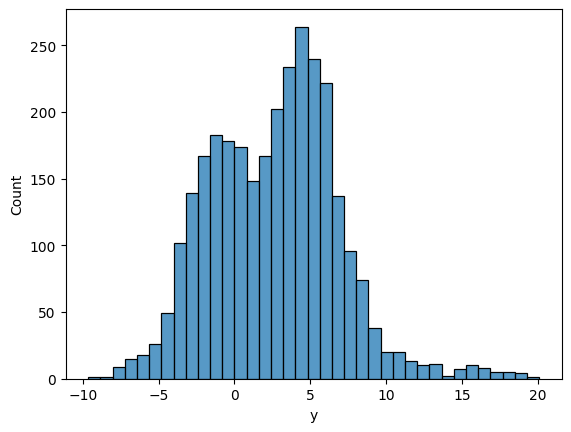

In [0]:
sns.histplot(df["y"])

## Cook's Distance

In [0]:
def compute_mixedlm_cooks_distance(
    data, 
    dep_var, 
    student_var, 
    school_var,
    school_re_df, 
    group_col='school', 
    n_jobs=-1
):
    """
    Compute Cook's Distance for hierarchical mixed linear models at both student and school levels.

    Parameters
    ----------
    data : pd.DataFrame
        Student-level data with predictors and outcome.
    dep_var : str
        Dependent variable name.
    student_var : str
        Student-level predictor variable name.
    school_var : str
        School-level predictor variable name.
    school_re_df : pd.DataFrame
        School-level random effect table with outlier flags.
    group_col : str, default='school'
        Column name for grouping (school).
    n_jobs : int, default=-1
        Number of parallel jobs for computation.

    Returns
    -------
    student_df : pd.DataFrame
        DataFrame with student-level Cook's D and influential flags.
    school_df : pd.DataFrame
        DataFrame with school-level Cook's D, influential flags, and random effect info.
    """
    
    data = data.reset_index(drop=True)
    n = len(data)
    formula = f"{dep_var} ~ {student_var} + {school_var}"

    # Fit full model
    model_full = MixedLM.from_formula(formula, groups=data[group_col], data=data)
    result_full = model_full.fit(reml=False)

    theta = result_full.fe_params.values
    theta_index = result_full.fe_params.index
    cov_theta = result_full.cov_params().loc[theta_index, theta_index].values
    cov_inv = np.linalg.pinv(cov_theta)
    p = len(theta)

    # Student-level Cook's D
    def student_cd(i):
        data_loo = data.drop(index=i)
        try:
            m = MixedLM.from_formula(formula, groups=data_loo[group_col], data=data_loo)
            r = m.fit(reml=False, maxiter=200)
            r_theta = r.fe_params.reindex(theta_index, fill_value=np.nan).values
            delta = theta - r_theta
            delta = np.nan_to_num(delta)
            return float((delta.T @ cov_inv @ delta) / p)
        except Exception as e:
            print(f"Student {i} refit failed: {e}")
            return np.nan

    student_cds = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(student_cd)(i) for i in range(n)
    )

    data = data.copy()
    data['student_cd'] = student_cds
    cutoff_student = 4 / n
    data['student_influential'] = (data['student_cd'] > cutoff_student).astype(int)

    # School-level Cook's D
    schools = data[group_col].unique()

    def school_cd(g):
        data_loo = data[data[group_col] != g]
        try:
            m = MixedLM.from_formula(formula, groups=data_loo[group_col], data=data_loo)
            r = m.fit(reml=False, maxiter=200)
            r_theta = r.fe_params.reindex(theta_index, fill_value=np.nan).values
            delta = theta - r_theta
            delta = np.nan_to_num(delta)
            return float((delta.T @ cov_inv @ delta) / p)
        except Exception as e:
            print(f"School {g} refit failed: {e}")
            return np.nan

    school_cds = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(school_cd)(g) for g in schools
    )

    school_df = pd.DataFrame({
        'school': schools,
        'school_cd': school_cds
    })

    G = len(schools)
    cutoff_sch = 4 / G
    school_df['school_influential'] = (school_df['school_cd'] > cutoff_sch).astype(int)

    # Merge random effect info
    school_df = school_df.merge(school_re_df, on='school', how='left')

    # Summary
    print(f"Students: {data['student_influential'].sum()}/{len(data)} outliers (cutoff={cutoff_student:.3f})")
    print(f"Schools: {school_df['school_influential'].sum()}/{G} outliers (cutoff={cutoff_sch:.3f})")

    return data, school_df

In [0]:
student_cd, school_cd = compute_mixedlm_cooks_distance(
        data=df,
        dep_var='y',
        student_var='x',
        school_var='ses',
        school_re_df=school_re_df,
        group_col='school',
        n_jobs=-1
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 640 tasks      | elapsed:   28.8s
[Parallel(n_jobs=-1)]: Done 874 tasks      | elapsed:   40.3s
[Parallel(n_jobs=-1)]: Done 1144 tasks      | elapsed:   52.0s
[Parallel(n_jobs=-1)]: Done 1450 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 2170 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 2584 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:  2.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Don

Students: 28/3000 outliers (cutoff=0.001)
Schools: 3/100 outliers (cutoff=0.040)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.2s finished


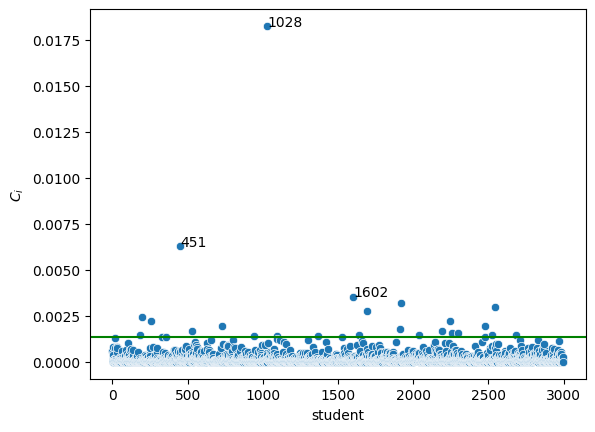

In [0]:
sns.scatterplot(data=student_cd, x='student', y='student_cd')
plt.ylabel(r'$C_i$')
plt.axhline(y=4/3000, color='green')
for i in [1028, 1602, 451]:
    plt.annotate(i, (i, student_cd['student_cd'][i]))

In [0]:
sum(student_cd['student_cd']>4/3000)

28

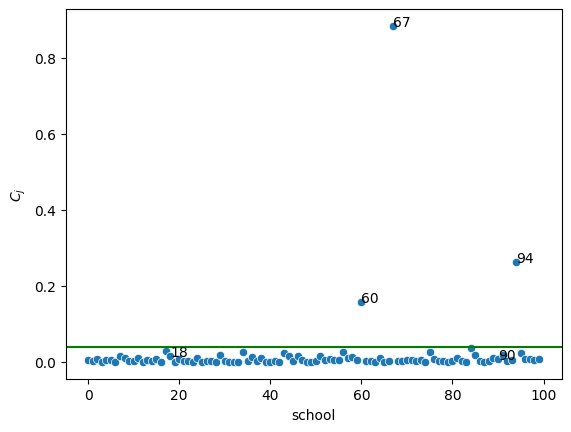

In [0]:
sns.scatterplot(data=school_cd, x='school', y='school_cd')
plt.ylabel(r'$C_j$')
plt.axhline(y=4/100, color='green')
for i in [90, 18, 60, 94, 67]:
    plt.annotate(i, (i, school_cd['school_cd'][i]))

### Random effects

In [0]:
def compute_mixedlm_random_intercept_cooks(data, dep_var, student_var, school_var,
                                           school_re_df,
                                           group_col='school', n_jobs=-1, alpha=0.05):
    
    data = data.reset_index(drop=True)
    n = len(data)
    formula = f"{dep_var} ~ {student_var} + {school_var}"
    
    # --------------------------
    # Fit full model
    # --------------------------
    model_full = MixedLM.from_formula(formula, groups=data[group_col], data=data)
    result_full = model_full.fit(reml=False)
    
    # Random effect variance and residual variance
    cov_re_diag = np.diag(result_full.cov_re).ravel()
    sigma2_u = cov_re_diag[0]                        # random intercept variance
    sigma2_e = result_full.scale.item() if hasattr(result_full.scale, 'item') else float(result_full.scale)  # residual variance
    
    theta = np.array([sigma2_u, sigma2_e])
    cov_theta = np.diag(theta)
    cov_inv = np.linalg.pinv(cov_theta)
    
    # Heuristic cutoff
    cutoff = 4 / n
    
    # --------------------------
    # Helper: extract theta from a fitted result
    # --------------------------
    def extract_theta(result):
        re_diag = np.diag(result.cov_re).ravel()
        su = re_diag[0]
        se = result.scale.item() if hasattr(result.scale, 'item') else float(result.scale)
        return np.array([su, se])
    
    # --------------------------
    # STUDENT-LEVEL COOK'S D
    # --------------------------
    def student_cd(i):
        data_loo = data.drop(index=i)
        try:
            m = MixedLM.from_formula(formula, groups=data_loo[group_col], data=data_loo)
            r = m.fit(reml=False, maxiter=200)
            r_theta = extract_theta(r)
            delta = theta - r_theta
            return float(delta.T @ cov_inv @ delta)
        except Exception as e:
            print(f"Student {i} refit failed: {e}")
            return np.nan
    
    student_cds = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(student_cd)(i) for i in range(n)
    )
    
    data = data.copy()
    data['student_cd'] = student_cds
    data['student_influential'] = (data['student_cd'] > cutoff).astype(int)
    
    # --------------------------
    # SCHOOL-LEVEL COOK'S D
    # --------------------------
    schools = data[group_col].unique()
    
    def school_cd(g):
        data_loo = data[data[group_col] != g]
        try:
            m = MixedLM.from_formula(formula, groups=data_loo[group_col], data=data_loo)
            r = m.fit(reml=False, maxiter=200)
            r_theta = extract_theta(r)
            delta = theta - r_theta
            return float(delta.T @ cov_inv @ delta)
        except Exception as e:
            print(f"School {g} refit failed: {e}")
            return np.nan
    
    school_cds = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(school_cd)(g) for g in schools
    )
    
    school_df = pd.DataFrame({
        'school': schools,
        'school_cd': school_cds
    })
    
    cutoff_sch = 4 / len(schools)
    school_df['school_influential'] = (school_df['school_cd'] > cutoff_sch).astype(int)

    # --------------------------
    # MERGE TRUE RANDOM EFFECT INFO
    # --------------------------
    school_df = school_df.merge(school_re_df, on='school', how='left')

    # Summary
    print(f"\n--- Variance Components (Full Model) ---")
    print(f"  sigma^2_u (random intercept): {sigma2_u:.6f}")
    print(f"  sigma^2_e (residual):         {sigma2_e:.6f}")
    print(f"\n--- Influence Diagnostics ---")
    print(f"Students: {data['student_influential'].sum()}/{len(data)} outliers (cutoff={cutoff:.3f})")
    print(f"Schools:  {school_df['school_influential'].sum()}/{len(schools)} outliers (cutoff={cutoff_sch:.3f})")
    
    return data, school_df

In [0]:
student_cd_re, school_cd_re = compute_mixedlm_random_intercept_cooks(
        data=df,
        dep_var='y',
        student_var='x',
        school_var='ses',
        group_col='school',
        school_re_df=school_re_df,
        n_jobs=-1
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 120 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 300 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 552 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-1)]: Done 876 tasks      | elapsed:   37.7s
[Parallel(n_jobs=-1)]: Done 1272 tasks      | elapsed:   55.7s
[Parallel(n_jobs=-1)]: Done 1740 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 2280 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 2892 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:  2.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.7s



--- Variance Components (Full Model) ---
  sigma^2_u (random intercept): 1.783253
  sigma^2_e (residual):         9.712325

--- Influence Diagnostics ---
Students: 0/3000 outliers (cutoff=0.001)
Schools:  1/100 outliers (cutoff=0.040)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.3s finished


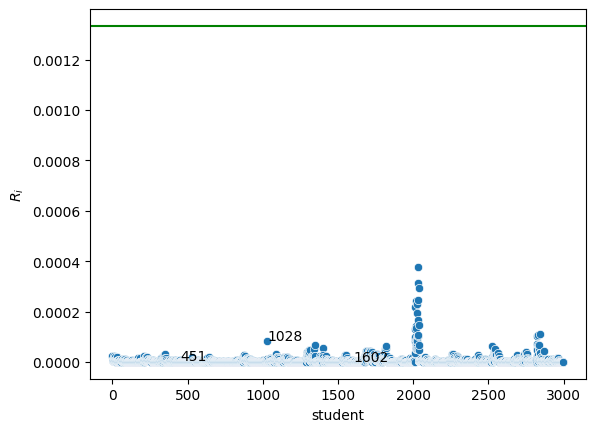

In [0]:
sns.scatterplot(data=student_cd_re, x='student', y='student_cd')
plt.ylabel(r'$R_i$')
plt.axhline(y=4/3000, color='green')
for i in [1028, 1602, 451]:
    plt.annotate(i, (i, student_cd_re['student_cd'][i]))

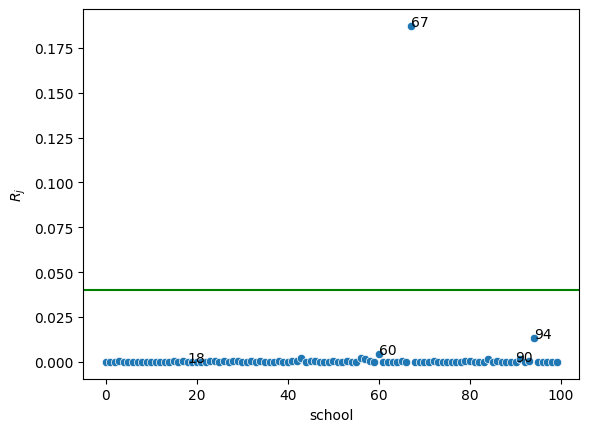

In [0]:
sns.scatterplot(data=school_cd_re, x='school', y='school_cd')
plt.ylabel(r'$R_j$')
plt.axhline(y=4/100, color='green')
for i in [90, 18, 60, 94, 67]:
    plt.annotate(i, (i, school_cd_re['school_cd'][i]))

## Linear IOM

### Student level

In [0]:
model_full = MixedLM.from_formula('y ~ x + ses', groups=df['school'], data=df)
result_full = model_full.fit(reml=False)
beta = result_full.fe_params[['x', 'ses']].values
X = df[['x', 'ses']].values
mu = X.mean(axis=0)

shap_values = (X - mu) * beta

In [0]:
shap_values_df = pd.DataFrame(shap_values, columns=['x_phi', "ses_phi"])
shap_values_df.loc[:, 'school'] = df['school']
shap_values_df.loc[:, 'resid'] = result_full.resid.values.reshape(-1)
shap_values_df.loc[:, 'student'] = df['student']
b_hat = pd.DataFrame(result_full.random_effects).T.reset_index().rename(columns={'index': 'school', "Group": 'b_hat'})
shap_values_df = shap_values_df.merge(b_hat, on=['school'], how='left')
results = shap_values_df

<Axes: ylabel='Count'>

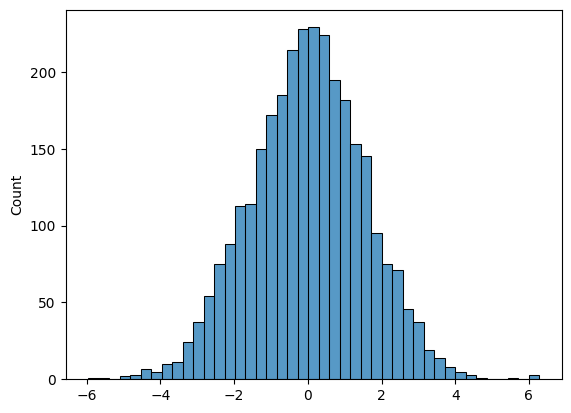

In [0]:
sns.histplot(shap_values_df['x_phi'].values)

In [0]:
linear_iom = InfluentialOutlierMetric()

In [0]:
results_iom_um = linear_iom.find_best_lambda(
    shap_values_df['x_phi'].values,
    K=6,
    hidden=6,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=7,
    num_bins=8,
    torch_seed=42
)

lambda: 0.0


Normalizing flow: 100%|██████████| 500/500 [00:47<00:00, 10.45it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.8842

[1b] Stouffer combined normality p-value
     z = -1.1961
     p = 0.8842
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8806
    CvM p-value: 0.7495
    Q mean:      0.9791  expected approx d=1
    Q max:       14.3439
    min tail p:  0.0001523
lambda: 0.006737946999085467


Normalizing flow: 100%|██████████| 500/500 [00:46<00:00, 10.76it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.8589

[1b] Stouffer combined normality p-value
     z = -1.0755
     p = 0.8589
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9113
    CvM p-value: 0.8143
    Q mean:      0.9816  expected approx d=1
    Q max:       14.4429
    min tail p:  0.0001445
lambda: 0.013123728736940968


...

--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.8154

[1b] Stouffer combined normality p-value
     z = -0.8981
     p = 0.8154
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9692
    CvM p-value: 0.9437
    Q mean:      1.0174  expected approx d=1
    Q max:       14.9923
    min tail p:  0.000108
lambda: 0.09697196786440505


Normalizing flow: 100%|██████████| 500/500 [00:45<00:00, 11.11it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.8401

[1b] Stouffer combined normality p-value
     z = -0.9951
     p = 0.8401
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.4453
    CvM p-value: 0.2694
    Q mean:      1.0486  expected approx d=1
    Q max:       15.1782
    min tail p:  9.783e-05
lambda: 0.18887560283756177


Normalizing flow: 100%|██████████| 500/500 [00:44<00:00, 11.15it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.8161

[1b] Stouffer combined normality p-value
     z = -0.9007
     p = 0.8161
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0327
    CvM p-value: 0.0120
    Q mean:      1.0928  expected approx d=1
    Q max:       15.6282
    min tail p:  7.71e-05
Final lambda: 0.0970
Mean test distance: 0.2043
Final weights: [1.0]
Final means: [array([0.0789])]
Final scales: [array([1.055])]


In [0]:
results_iom_bm = linear_iom.find_best_lambda(
    shap_values_df['x_phi'].values,
    K=6,
    hidden=6,
    layers=2,
    epoch=500,
    loc=[-3,3],
    scale=[1,1],
    tail_bound=7,
    num_bins=14,
    torch_seed=42
)

lambda: 0.0


Normalizing flow: 100%|██████████| 500/500 [00:44<00:00, 11.14it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1417  test: Jarque-Bera  pvalue: 0.9260
    mode: 1  n: 1583  test: Jarque-Bera  pvalue: 0.9813

[1b] Stouffer combined normality p-value
     z = -2.4954
     p = 0.9937
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9875
    CvM p-value: 0.9940
    Q mean:      1.0063  expected approx d=1
    Q max:       10.7939
    min tail p:  0.001018
lambda: 0.006737946999085467


Normalizing flow: 100%|██████████| 500/500 [00:44<00:00, 11.18it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1418  test: Jarque-Bera  pvalue: 0.9624
    mode: 1  n: 1582  test: Jarque-Bera  pvalue: 0.9469

[1b] Stouffer combined normality p-value
     z = -2.4004
     p = 0.9918
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9951
    CvM p-value: 0.9965
    Q mean:      1.0049  expected approx d=1
    Q max:       10.8175
    min tail p:  0.001005
lambda: 0.013123728736940968


...

--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1419  test: Jarque-Bera  pvalue: 0.5405
    mode: 1  n: 1581  test: Jarque-Bera  pvalue: 0.9762

[1b] Stouffer combined normality p-value
     z = -1.4725
     p = 0.9296
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9592
    CvM p-value: 0.9455
    Q mean:      0.9897  expected approx d=1
    Q max:       10.9205
    min tail p:  0.0009511
lambda: 0.049787068367863944


Normalizing flow: 100%|██████████| 500/500 [00:44<00:00, 11.14it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1419  test: Jarque-Bera  pvalue: 0.3280
    mode: 1  n: 1581  test: Jarque-Bera  pvalue: 0.7437

[1b] Stouffer combined normality p-value
     z = -0.1482
     p = 0.5589
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9656
    CvM p-value: 0.9262
    Q mean:      0.9827  expected approx d=1
    Q max:       10.9973
    min tail p:  0.0009125
lambda: 0.09697196786440505


Normalizing flow: 100%|██████████| 500/500 [00:44<00:00, 11.18it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1421  test: Jarque-Bera  pvalue: 0.0425
    mode: 1  n: 1579  test: Jarque-Bera  pvalue: 0.2118

[1b] Stouffer combined normality p-value
     z = 1.7836
     p = 0.03725
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9090
    CvM p-value: 0.8637
    Q mean:      0.9717  expected approx d=1
    Q max:       11.1293
    min tail p:  0.0008497
Final lambda: 0.0498
Mean test distance: 3.0863
Final weights: [0.4777, 0.5223]
Final means: [array([-2.973]), array([2.9745])]
Final scales: [array([1.0202]), array([1.0246])]


In [0]:
linear_iom.select_flow_by_transport_modes([results_iom_um, results_iom_bm])

{'selected_index': 0,
 'table': [{'index': 0,
   'M': 0.20428453385829926,
   'n_modes': 1,
   'K_m': 2,
   'rho': 0.34657359027997264,
   'score': 0.8974317144182445},
  {'index': 1,
   'M': 3.0862817764282227,
   'n_modes': 2,
   'K_m': 5,
   'rho': 0.34657359027997264,
   'score': 4.819149727828086}]}

#### Residuals

<Axes: ylabel='Count'>

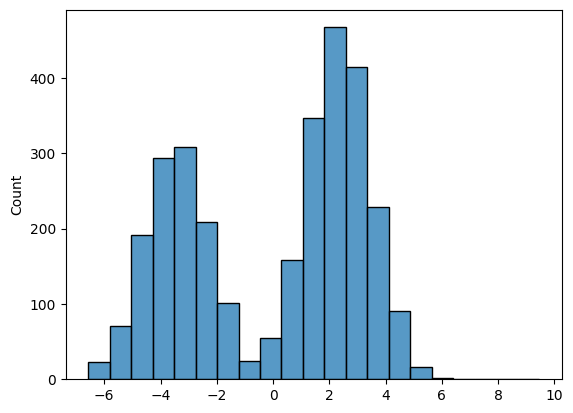

In [0]:
sns.histplot(results['resid'].values)

In [0]:
results_iom_resid_um = linear_iom.find_best_lambda(
    results['resid'].values,
    K=12,
    hidden=12,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=10,
    num_bins=8,
    torch_seed=42
)

lambda: 0.0


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [03:07<00:00,  5.32it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.6127

[1b] Stouffer combined normality p-value
     z = -0.2863
     p = 0.6127
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5405
    CvM p-value: 0.3251
    Q mean:      0.9708  expected approx d=1
    Q max:       16.0007
    min tail p:  6.332e-05
lambda: 0.006737946999085467


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [03:01<00:00,  5.52it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.6106

[1b] Stouffer combined normality p-value
     z = -0.2808
     p = 0.6106
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8778
    CvM p-value: 0.7519
    Q mean:      0.9841  expected approx d=1
    Q max:       16.8706
    min tail p:  4.002e-05
lambda: 0.013123728736940968


...

--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.7134

[1b] Stouffer combined normality p-value
     z = -0.5634
     p = 0.7134
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9888
    CvM p-value: 0.9743
    Q mean:      0.9924  expected approx d=1
    Q max:       17.0098
    min tail p:  3.719e-05
lambda: 0.025561533206507392


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [03:00<00:00,  5.53it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.8751

[1b] Stouffer combined normality p-value
     z = -1.1507
     p = 0.8751
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7868
    CvM p-value: 0.7793
    Q mean:      1.0118  expected approx d=1
    Q max:       17.3630
    min tail p:  3.088e-05
lambda: 0.049787068367863944


N

*** WARNING: max output size exceeded, skipping output. ***

Normalizing flow: 100%|██████████| 1000/1000 [03:04<00:00,  5.41it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.9654

[1b] Stouffer combined normality p-value
     z = -1.8166
     p = 0.9654
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0694
    CvM p-value: 0.0469
    Q mean:      1.0409  expected approx d=1
    Q max:       17.6540
    min tail p:  2.65e-05
Final lambda: 0.0256
Mean test distance: 4.2798
Final weights: [1.0]
Final means: [array([-0.0008])]
Final scales: [array([1.0273])]


In [0]:
results_iom_resid_bm = linear_iom.find_best_lambda(
    results['resid'].values,
    lambdas= np.concatenate([np.array([0]), np.exp(np.linspace(-1, 5, 10))]),
    K=4,
    hidden=4,
    layers=2,
    epoch=1000,
    loc=[-3.5, 3.5],
    scale=[1,1],
    tail_bound=10,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0


Normalizing flow: 100%|██████████| 1000/1000 [01:04<00:00, 15.56it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1218  test: Jarque-Bera  pvalue: 0.9187
    mode: 1  n: 1782  test: Jarque-Bera  pvalue: 0.1097

[1b] Stouffer combined normality p-value
     z = -0.1188
     p = 0.5473
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.3624
    CvM p-value: 0.2836
    Q mean:      0.9812  expected approx d=1
    Q max:       18.3614
    min tail p:  1.827e-05
lambda: 0.36787944117144233


Normalizing flow: 100%|██████████| 1000/1000 [01:00<00:00, 16.61it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1217  test: Jarque-Bera  pvalue: 0.6572
    mode: 1  n: 1783  test: Jarque-Bera  pvalue: 0.2352

[1b] Stouffer combined normality p-value
     z = 0.2241
     p = 0.4113
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9117
    CvM p-value: 0.9103
    Q mean:      0.9923  expected approx d=1
    Q max:       20.1316
    min tail p:  7.229e-06
lambda: 0.7165313105737893


...

--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1217  test: Jarque-Bera  pvalue: 0.4622
    mode: 1  n: 1783  test: Jarque-Bera  pvalue: 0.0611

[1b] Stouffer combined normality p-value
     z = 1.1601
     p = 0.123
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.6081
    CvM p-value: 0.7878
    Q mean:      0.9887  expected approx d=1
    Q max:       25.7756
    min tail p:  3.835e-07
lambda: 5.294490050470029


Normalizing flow: 100%|██████████| 1000/1000 [01:00<00:00, 16.56it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1217  test: Jarque-Bera  pvalue: 0.3471
    mode: 1  n: 1783  test: Jarque-Bera  pvalue: 0.0271

[1b] Stouffer combined normality p-value
     z = 1.6394
     p = 0.05057
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.7299
    CvM p-value: 0.7136
    Q mean:      0.9866  expected approx d=1
    Q max:       27.3678
    min tail p:  1.682e-07
lambda: 10.312258501325761


Normalizing flow: 100%|██████████| 1000/1000 [01:00<00:00, 16.44it/s]

--- Whitened mode-normality diagnostics (n=3000, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1217  test: Jarque-Bera  pvalue: 0.2620
    mode: 1  n: 1783  test: Jarque-Bera  pvalue: 0.0087

[1b] Stouffer combined normality p-value
     z = 2.1320
     p = 0.0165
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.7328
    CvM p-value: 0.6762
    Q mean:      0.9849  expected approx d=1
    Q max:       28.6108
    min tail p:  8.849e-08
Final lambda: 5.2945
Mean test distance: 0.5005
Final weights: [0.4183, 0.5817]
Final means: [array([-3.2944]), array([3.3571])]
Final scales: [array([1.1419]), array([1.1377])]


In [0]:
linear_iom.select_flow_by_transport_modes([results_iom_resid_um, results_iom_resid_bm])

{'selected_index': 1,
 'table': [{'index': 0,
   'M': 4.279841899871826,
   'n_modes': 1,
   'K_m': 2,
   'rho': 0.34657359027997264,
   'score': 4.972989080431772},
  {'index': 1,
   'M': 0.5004665851593018,
   'n_modes': 2,
   'K_m': 5,
   'rho': 0.34657359027997264,
   'score': 2.2333345365591653}]}

In [0]:
IOM = linear_iom.IOM(results_iom_um, results_iom_resid_bm)

In [0]:
results['IOM_i'] = IOM
results['student_outlier'] = df['student_outlier']
results['school_outlier'] = df['school_outlier']

In [0]:
sum(results['IOM_i'] > 12.9904)

41

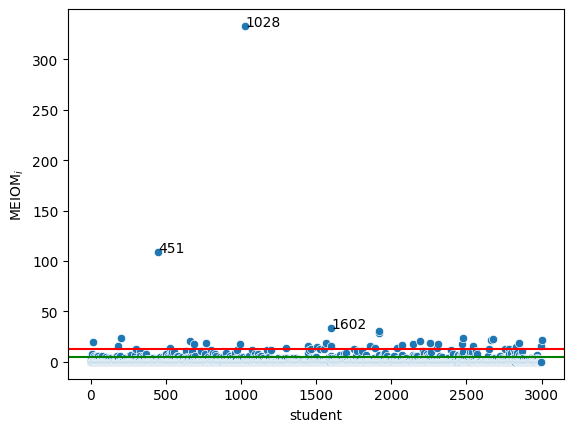

In [0]:
sns.scatterplot(data=results, x='student', y='IOM_i')
plt.ylabel(r'$\mathrm{MEIOM}_i$')
plt.axhline(y=4.7609, color='green')
plt.axhline(y=12.9904, color='red')
for i in [1028, 451, 1602]:
    plt.annotate(i, (i, results['IOM_i'][i]))

### School level

In [0]:
results_school = results[['school', 'ses_phi', 'b_hat']].drop_duplicates().reset_index(drop=True)

<Axes: ylabel='Count'>

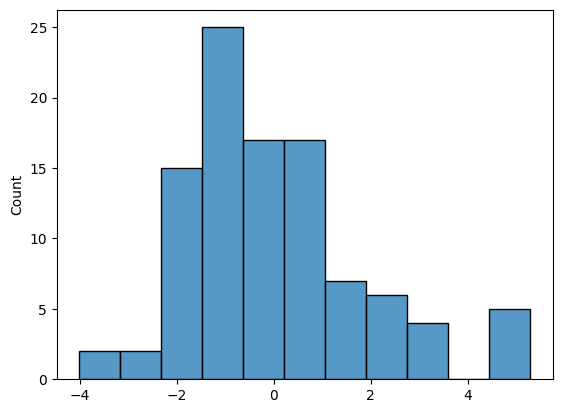

In [0]:
sns.histplot(results_school['ses_phi'].values)

In [0]:
linear_iom_sch = InfluentialOutlierMetric()

In [0]:
results_iom_sch = linear_iom_sch.find_best_lambda(
    results_school['ses_phi'].values,
    K=6,
    hidden=6,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=6,
    num_bins=12,
    torch_seed=42
)

lambda: 0.0


Normalizing flow:  36%|███▋      | 182/500 [00:16<00:26, 12.04it/s]

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

<Axes: ylabel='Count'>

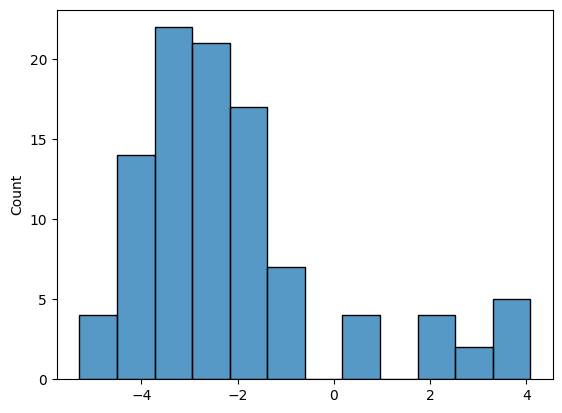

In [0]:
sns.histplot(results_iom_sch_bm['latent'])

#### Residuals

<Axes: ylabel='Count'>

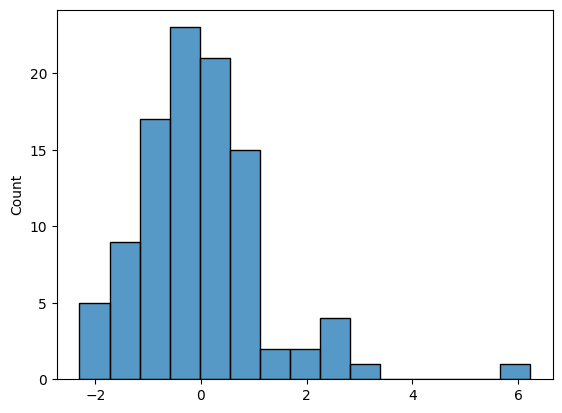

In [0]:
sns.histplot(results_school['b_hat'].values)

In [0]:
results_iom_sch_resid = linear_iom_sch.find_best_lambda(
    results_school['b_hat'].values,
    lambdas= np.concatenate([np.array([0]), np.exp(np.linspace(-1, 5, 10))]),
    K=6,
    hidden=6,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=7,
    num_bins=10,
    torch_seed=42
)

lambda: 0.0


Normalizing flow: 100%|██████████| 500/500 [00:42<00:00, 11.86it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.9047

[1b] Stouffer combined normality p-value
     z = -1.3089
     p = 0.9047
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8565
    CvM p-value: 0.7277
    Q mean:      0.9209  expected approx d=1
    Q max:       7.7867
    min tail p:  0.005263
lambda: 0.36787944117144233


Normalizing flow: 100%|██████████| 500/500 [00:42<00:00, 11.74it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.8933

[1b] Stouffer combined normality p-value
     z = -1.2441
     p = 0.8933
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8790
    CvM p-value: 0.7228
    Q mean:      0.8692  expected approx d=1
    Q max:       6.9214
    min tail p:  0.008517
lambda: 0.7165313105737893


...

--- Whitened mode-normality diagnostics (n=100, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.3942

[1b] Stouffer combined normality p-value
     z = 0.2685
     p = 0.3942
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6177
    CvM p-value: 0.6257
    Q mean:      0.9189  expected approx d=1
    Q max:       7.3041
    min tail p:  0.00688
lambda: 76.19785657297057


Normalizing flow: 100%|██████████| 500/500 [00:42<00:00, 11.83it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.0663

[1b] Stouffer combined normality p-value
     z = 1.5040
     p = 0.06629
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5064
    CvM p-value: 0.5535
    Q mean:      0.9682  expected approx d=1
    Q max:       9.4749
    min tail p:  0.002083
lambda: 148.4131591025766


Normalizing flow: 100%|██████████| 500/500 [00:42<00:00, 11.85it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.0035

[1b] Stouffer combined normality p-value
     z = 2.6938
     p = 0.003532
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5624
    CvM p-value: 0.4341
    Q mean:      0.9987  expected approx d=1
    Q max:       11.8907
    min tail p:  0.0005642
Final lambda: 76.1979
Mean test distance: 0.0234
Final weights: [1.0]
Final means: [array([0.068])]
Final scales: [array([1.0977])]


In [0]:
results_iom_sch_resid_bm = linear_iom_sch.find_best_lambda(
    results_school['b_hat'].values,
    lambdas= np.concatenate([np.array([0]), np.exp(np.linspace(-1, 5, 10))]),
    K=6,
    hidden=6,
    layers=2,
    epoch=500,
    loc=[-3,3],
    scale=[1,1],
    tail_bound=7,
    num_bins=10,
    torch_seed=42
)

In [0]:
linear_iom.select_flow_by_transport_modes([results_iom_sch, results_iom_sch_bm])

In [0]:
IOM_sch = linear_iom_sch.IOM(results_iom_sch, results_iom_sch_resid)

In [0]:
results_school['IOM'] = IOM_sch
results_school = results_school.merge(school_re_df, on='school', how='left')

In [0]:
sum(results_school['IOM'] > 12.99)

3

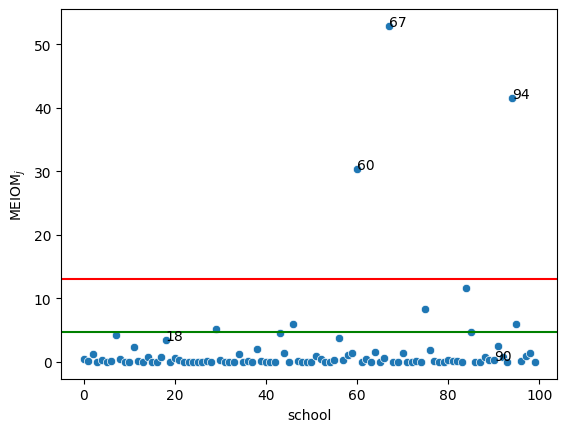

In [0]:
sns.scatterplot(data=results_school, x='school', y='IOM')
plt.ylabel(r'$\mathrm{MEIOM}_j$')
plt.axhline(y=4.7609, color='green')
plt.axhline(y=12.9904, color='red')
for i in [90, 18, 60, 94, 67]:
    plt.annotate(i, (i, results_school['IOM'][i]))

## RF IOM

In [6]:
import random
import os
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
# ---------------------------------------------------------------
# Global reproducibility
# ---------------------------------------------------------------
SEED = 42

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_global_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ---------------------------------------------------------------
# MERF class
# ---------------------------------------------------------------
class MERF_CPU:
    def __init__(self, rf_params=None, max_iter=6, tol=1e-4, random_state=42):
        rf_params = dict(rf_params or {})
        rf_params.setdefault("n_estimators", 200)
        rf_params.setdefault("max_depth", 12)
        rf_params.setdefault("random_state", random_state)
        rf_params.setdefault("n_jobs", 1)
        rf_params.setdefault("bootstrap", True)
        rf_params.setdefault("warm_start", True)

        self.rf_params = rf_params
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.rf = RF(**self.rf_params)
        self.gamma = None
        self.group_map = None
        self.sigma2_hat = None

    def fit(self, X, y, groups):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        groups = np.asarray(groups)

        unique_groups, group_idx = np.unique(groups, return_inverse=True)
        counts = np.bincount(group_idx).astype(np.float32)

        gamma = np.zeros(len(unique_groups), dtype=np.float32)
        mu_hat = np.zeros_like(y)
        sigma2 = float(np.var(y))
        n_trees_base = self.rf.n_estimators

        for it in range(self.max_iter):
            self.rf.n_estimators = n_trees_base * (it + 1)
            self.rf.fit(X, y - gamma[group_idx])
            mu_hat[:] = self.rf.predict(X)

            resid = y - mu_hat
            gamma_new = np.bincount(group_idx, weights=resid) / counts

            resid_full = y - (mu_hat + gamma_new[group_idx])
            sigma2_new = float(np.mean(resid_full ** 2))

            if abs(sigma2_new - sigma2) < self.tol * (sigma2 + 1e-12):
                gamma = gamma_new
                sigma2 = sigma2_new
                break

            gamma = gamma_new
            sigma2 = sigma2_new

        self.gamma = gamma
        self.group_map = dict(zip(unique_groups, np.arange(len(unique_groups))))
        self.sigma2_hat = sigma2
        return self

    def predict(self, X, groups):
        X = np.asarray(X, dtype=np.float32)
        groups = np.asarray(groups)

        y_fe = self.rf.predict(X)
        idx = np.array([self.group_map.get(g, -1) for g in groups], dtype=int)

        re = np.zeros(len(groups), dtype=np.float32)
        mask = idx >= 0
        re[mask] = self.gamma[idx[mask]]

        return y_fe + re


# ---------------------------------------------------------------
# CV split builder
# ---------------------------------------------------------------
def make_splits(X, y, groups, cv_strategy="kfold", n_splits=5, seed=SEED):
    if cv_strategy == "group":
        splitter = GroupKFold(n_splits=n_splits)
        return list(splitter.split(X, y, groups))
    elif cv_strategy == "kfold":
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return list(splitter.split(X, y))
    else:
        raise ValueError("cv_strategy must be 'group' or 'kfold'")


# ---------------------------------------------------------------
# Objective for 1-feature regularized RF
# ---------------------------------------------------------------
def make_objective(X, y, groups, splits, seed=SEED):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    groups = np.asarray(groups)

    n_train_approx = len(y) - len(y) // len(splits)

    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 300, step=50),
            "max_depth":         trial.suggest_int("max_depth", 2, 6),
            "min_samples_leaf":  trial.suggest_int(
                "min_samples_leaf",
                max(5, n_train_approx // 200),
                max(50, n_train_approx // 20),
                log=True,
            ),
            "min_samples_split": trial.suggest_int("min_samples_split", 10, 100, log=True),
            "ccp_alpha":         trial.suggest_float("ccp_alpha", 1e-5, 1e-1, log=True),
            "max_samples":       trial.suggest_float("max_samples", 0.3, 0.9),
            "max_iter":          trial.suggest_int("max_iter", 2, 5),
        }

        fold_rmses = []
        for fold_id, (tr, va) in enumerate(splits):
            fold_seed = seed + 1000 * trial.number + fold_id

            rf_params = {
                "n_estimators":      params["n_estimators"],
                "max_depth":         params["max_depth"],
                "min_samples_leaf":  params["min_samples_leaf"],
                "min_samples_split": params["min_samples_split"],
                "ccp_alpha":         params["ccp_alpha"],
                "max_samples":       params["max_samples"],
                "max_features":      1.0,
                "random_state":      fold_seed,
                "n_jobs":            1,
                "bootstrap":         True,
                "warm_start":        True,
            }

            model = MERF_CPU(
                rf_params=rf_params,
                max_iter=params["max_iter"],
                tol=1e-4,
                random_state=fold_seed,
            )
            model.fit(X[tr], y[tr], groups[tr])
            y_pred = model.predict(X[va], groups[va])
            rmse = float(np.sqrt(mean_squared_error(y[va], y_pred)))
            fold_rmses.append(rmse)

        return float(np.mean(fold_rmses))

    return objective


# ---------------------------------------------------------------
# Tuning entry point
# ---------------------------------------------------------------
def tune_merf_optuna(X, y, groups, n_trials=50, cv_strategy="kfold",
                    n_splits=5, seed=SEED):
    set_global_seed(seed)
    splits = make_splits(X, y, groups, cv_strategy=cv_strategy,
                         n_splits=n_splits, seed=seed)

    sampler = TPESampler(
        seed=seed,
        n_startup_trials=10,
        multivariate=True,
        warn_independent_sampling=False,
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        study_name="merf_tuning",
    )

    objective = make_objective(X, y, groups, splits, seed=seed)
    study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)
    return study


# ---------------------------------------------------------------
# Build final model from best params
# ---------------------------------------------------------------
def fit_final_merf(X, y, groups, best_params, seed=SEED):
    rf_params = {
        "n_estimators":      best_params["n_estimators"],
        "max_depth":         best_params["max_depth"],
        "min_samples_leaf":  best_params["min_samples_leaf"],
        "min_samples_split": best_params["min_samples_split"],
        "ccp_alpha":         best_params["ccp_alpha"],
        "max_samples":       best_params["max_samples"],
        "max_features":      1.0,
        "random_state":      seed,
        "n_jobs":            1,
        "bootstrap":         True,
        "warm_start":        True,
    }

    final_model = MERF_CPU(
        rf_params=rf_params,
        max_iter=best_params["max_iter"],
        tol=1e-4,
        random_state=seed,
    )
    final_model.fit(X, y, groups)
    return final_model




In [10]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    df[['x', 'ses']], df['y'], df['school'], test_size=0.2, random_state=42
)

study = tune_merf_optuna(
        X_train, y_train, groups_train,
        n_trials=40,
        cv_strategy="kfold",
        n_splits=5,
        seed=SEED,
    )

model = fit_final_merf(X_train, y_train, groups_train, study.best_params, seed=SEED)

model.fit(X_train, y_train, groups_train)
np.sqrt(mean_squared_error(model.predict(X_test, groups_test), y_test))

/tmp/ipykernel_850/2473338281.py:172: FutureWarning: `warn_independent_sampling` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  sampler = TPESampler(
/tmp/ipykernel_850/2473338281.py:172: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = TPESampler(


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:466: UserWarning: Warm-start fitting without increasing n_estimators does not fit new trees.
  warn(


np.float64(3.115315227037707)

In [11]:
explainer = shap.TreeExplainer(model.rf)
shap_values_rf = explainer.shap_values(df[['x', 'ses']])

resid_rf = df['y'] - model.predict(df[['x', 'ses']], df['school'])

### Student level

<Axes: ylabel='Count'>

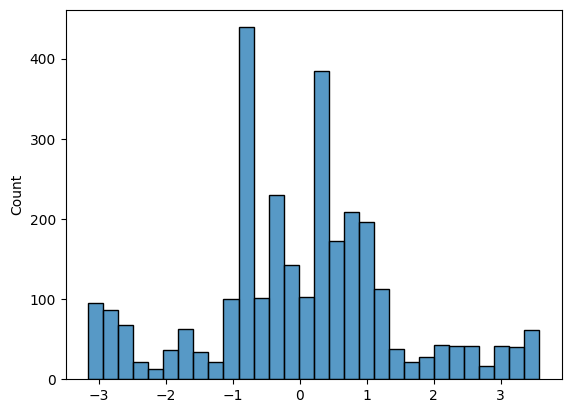

In [12]:
sns.histplot(shap_values_rf[:,0])

In [19]:
merf_iom = InfluentialOutlierMetric()

In [20]:
results_iom_um = merf_iom.find_best_lambda(
    shap_values_rf[:, 0],
    K=6,
    hidden=6,
    layers=4,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=4,
    num_bins=24,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [01:29<00:00,  5.59it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.2385

[1b] Stouffer combined normality p-value
     z = 0.7112
     p = 0.2385
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6707
    CvM p-value: 0.5436
    Q mean:      0.9528  expected approx d=1
    Q max:       8.1810
    min tail p:  0.004233
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [01:29<00:00,  5.61it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.1828

[1b] Stouffer combined normality p-value
     z = 0.9047
     p = 0.1828
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6993
    CvM p-value: 0.6848
    Q mean:      0.9563  expected approx d=1
    Q max:       8.1972
    min tail p:  0.004196
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.2243

[1b] Stouffer combined normality p-value
     z = 0.7578
     p = 0.2243
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1699
    CvM p-value: 0.3723
    Q mean:      0.9621  expected approx d=1
    Q max:       7.7859
    min tail p:  0.005266
lambda: 0.09697196786440505
cuda


Normalizing flow: 100%|██████████| 500/500 [01:34<00:00,  5.29it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.1193

[1b] Stouffer combined normality p-value
     z = 1.1787
     p = 0.1193
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0645
    CvM p-value: 0.1885
    Q mean:      0.9677  expected approx d=1
    Q max:       7.5301
    min tail p:  0.006068
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [01:29<00:00,  5.57it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.0372

[1b] Stouffer combined normality p-value
     z = 1.7838
     p = 0.03723
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0028
    CvM p-value: 0.0259
    Q mean:      0.9735  expected approx d=1
    Q max:       7.0510
    min tail p:  0.007922
Final lambda: 0.0970
Mean test distance: 0.2027
Final weights: [np.float32(1.0)]
Final means: [array([0.0074], dtype=float32)]
Final scales: [array([1.0086], dtype=float32)]


In [21]:
results_iom_bm = merf_iom.find_best_lambda(
    shap_values_rf[:, 0],
    K=6,
    hidden=6,
    layers=4,
    epoch=1000,
    loc=[-3,3],
    scale=[1,1],
    tail_bound=6,
    num_bins=24,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:57<00:00,  5.63it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1499  test: Jarque-Bera  pvalue: 0.2756
    mode: 1  n: 1501  test: Jarque-Bera  pvalue: 0.3088

[1b] Stouffer combined normality p-value
     z = 0.7744
     p = 0.2194
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.5716
    CvM p-value: 0.3630
    Q mean:      0.9507  expected approx d=1
    Q max:       8.4615
    min tail p:  0.003627
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:58<00:00,  5.60it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1501  test: Jarque-Bera  pvalue: 0.4224
    mode: 1  n: 1499  test: Jarque-Bera  pvalue: 0.2495

[1b] Stouffer combined normality p-value
     z = 0.6164
     p = 0.2688
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.4289
    CvM p-value: 0.3070
    Q mean:      0.9476  expected approx d=1
    Q max:       8.6742
    min tail p:  0.003228
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1503  test: Jarque-Bera  pvalue: 0.5783
    mode: 1  n: 1497  test: Jarque-Bera  pvalue: 0.2485

[1b] Stouffer combined normality p-value
     z = 0.3404
     p = 0.3668
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.5716
    CvM p-value: 0.3192
    Q mean:      0.9500  expected approx d=1
    Q max:       8.6267
    min tail p:  0.003313
lambda: 0.025561533206507392
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:59<00:00,  5.57it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1501  test: Jarque-Bera  pvalue: 0.4668
    mode: 1  n: 1499  test: Jarque-Bera  pvalue: 0.3538

[1b] Stouffer combined normality p-value
     z = 0.3240
     p = 0.373
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.2946
    CvM p-value: 0.1320
    Q mean:      0.9370  expected approx d=1
    Q max:       8.6333
    min tail p:  0.003301
lambda: 0.049787068367863944
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:59<00:00,  5.56it/s]

--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1526  test: Jarque-Bera  pvalue: 0.2731
    mode: 1  n: 1474  test: Jarque-Bera  pvalue: 0.1735

[1b] Stouffer combined normality p-value
     z = 1.0918
     p = 0.1375
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.0394
    CvM p-value: 0.0391
    Q mean:      0.9231  expected approx d=1
    Q max:       8.2628
    min tail p:  0.004047
Final lambda: 0.0256
Mean test distance: 3.5316
Final weights: [np.float32(0.5042), np.float32(0.4958)]
Final means: [array([-2.9525], dtype=float32), array([2.9536], dtype=float32)]
Final scales: [array([0.9976], dtype=float32), array([0.9968], dtype=float32)]


In [22]:
merf_iom.select_flow_by_transport_modes([results_iom_um, results_iom_bm])

{'selected_index': 0,
 'table': [{'index': 0,
   'M': 0.20265761017799377,
   'n_modes': 1,
   'K_m': 2,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(0.8958047907379391)},
  {'index': 1,
   'M': 3.531611442565918,
   'n_modes': 2,
   'K_m': 5,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(5.2644793939657815)}]}

#### Residuals

<Axes: ylabel='Count'>

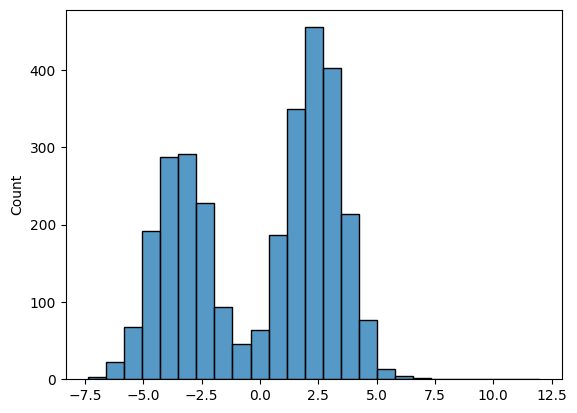

In [23]:
sns.histplot(resid_rf.values)

In [24]:
results_iom_resid_um = merf_iom.find_best_lambda(
    resid_rf.values,
    lambdas= np.concatenate([np.array([0]), np.exp(np.linspace(-1, 5, 10))]),
    K=12,
    hidden=12,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=13,
    num_bins=32,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [05:22<00:00,  3.10it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.1434

[1b] Stouffer combined normality p-value
     z = 1.0653
     p = 0.1434
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9885
    CvM p-value: 0.9923
    Q mean:      1.0195  expected approx d=1
    Q max:       20.5631
    min tail p:  5.77e-06
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 1000/1000 [05:22<00:00,  3.10it/s]

--- Whitened mode-normality diagnostics (n=3000, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 3000  test: Jarque-Bera  pvalue: 0.0000

[1b] Stouffer combined normality p-value
     z = 4.5268
     p = 2.994e-06
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0000
    CvM p-value: 0.0000
    Q mean:      1.3909  expected approx d=1
    Q max:       20.3216
    min tail p:  6.546e-06
Final lambda: 0.0000
Mean test distance: 4.5169
Final weights: [np.float32(1.0)]
Final means: [array([0.0098], dtype=float32)]
Final scales: [array([1.0094], dtype=float32)]


In [25]:
results_iom_resid_bm = merf_iom.find_best_lambda(
    resid_rf.values,
    lambdas= np.concatenate([np.array([0]), np.exp(np.linspace(-1, 5, 10))]),
    K=6,
    hidden=6,
    layers=2,
    epoch=1000,
    loc=[-4,4],
    scale=[1, 1],
    tail_bound=13,
    num_bins=32,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:42<00:00,  6.17it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1223  test: Jarque-Bera  pvalue: 0.5450
    mode: 1  n: 1777  test: Jarque-Bera  pvalue: 0.1510

[1b] Stouffer combined normality p-value
     z = 0.6500
     p = 0.2578
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9621
    CvM p-value: 0.9772
    Q mean:      1.0089  expected approx d=1
    Q max:       22.2930
    min tail p:  2.341e-06
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:50<00:00,  5.86it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1223  test: Jarque-Bera  pvalue: 0.7165
    mode: 1  n: 1777  test: Jarque-Bera  pvalue: 0.1832

[1b] Stouffer combined normality p-value
     z = 0.2339
     p = 0.4075
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.5363
    CvM p-value: 0.2121
    Q mean:      1.0372  expected approx d=1
    Q max:       19.3558
    min tail p:  1.085e-05
lambda: 0.7165313105737893
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:53<00:00,  5.77it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1223  test: Jarque-Bera  pvalue: 0.4664
    mode: 1  n: 1777  test: Jarque-Bera  pvalue: 0.1689

[1b] Stouffer combined normality p-value
     z = 0.7375
     p = 0.2304
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.2866
    CvM p-value: 0.1221
    Q mean:      1.0378  expected approx d=1
    Q max:       18.2688
    min tail p:  1.918e-05
lambda: 1.3956124250860895
cuda


Normalizing flow: 100%|██████████| 1000/1000 [02:42<00:00,  6.14it/s]


--- Whitened mode-normality diagnostics (n=3000, d=1, m=2) ---

[1] Normality by assigned mode
    mode: 0  n: 1223  test: Jarque-Bera  pvalue: 0.3087
    mode: 1  n: 1777  test: Jarque-Bera  pvalue: 0.1260

[1b] Stouffer combined normality p-value
     z = 1.1634
     p = 0.1223
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.0951
    CvM p-value: 0.0275
    Q mean:      1.0466  expected approx d=1
    Q max:       16.8706
    min tail p:  4.002e-05
Final lambda: 0.7165
Mean test distance: 1.7012
Final weights: [np.float32(0.419), np.float32(0.581)]
Final means: [array([-3.9669], dtype=float32), array([3.9753], dtype=float32)]
Final scales: [array([1.0819], dtype=float32), array([1.102], dtype=float32)]


In [26]:
merf_iom.select_flow_by_transport_modes([results_iom_resid_um, results_iom_resid_bm])

{'selected_index': 1,
 'table': [{'index': 0,
   'M': 4.5169219970703125,
   'n_modes': 1,
   'K_m': 2,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(5.210069177630258)},
  {'index': 1,
   'M': 1.7011945247650146,
   'n_modes': 2,
   'K_m': 5,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(3.434062476164878)}]}

In [27]:
IOM_merf = merf_iom.IOM(results_iom_um, results_iom_resid_bm)

In [28]:
iom_i_rf = pd.DataFrame(IOM_merf).reset_index().rename({'index': 'student'}, axis=1)

In [29]:
iom_i_rf['shap_z'] = results_iom_um['chi_z']
iom_i_rf['resid_z'] = results_iom_resid_bm['chi_z']


In [31]:
iom_i_rf.sort_values('IOM', ascending=False)

,student,IOM,shap_z,resid_z
1028,1028,1.375661e+02,7.530090,1.826885e+01
1694,1694,9.207435e+01,6.381992,1.442721e+01
731,731,5.458596e+01,7.410333,7.366195e+00
451,451,3.488365e+01,3.592188,9.710975e+00
1447,1447,2.833093e+01,4.227618,6.701392e+00
...,...,...,...,...
1497,1497,1.037545e-07,0.000292,3.549347e-04
1889,1889,6.570099e-08,1.063142,6.179889e-08
869,869,4.049700e-08,0.013855,2.922905e-06
2413,2413,8.197397e-09,0.134568,6.091631e-08


In [32]:
sum(iom_i_rf['IOM'] > 12.9904)

37

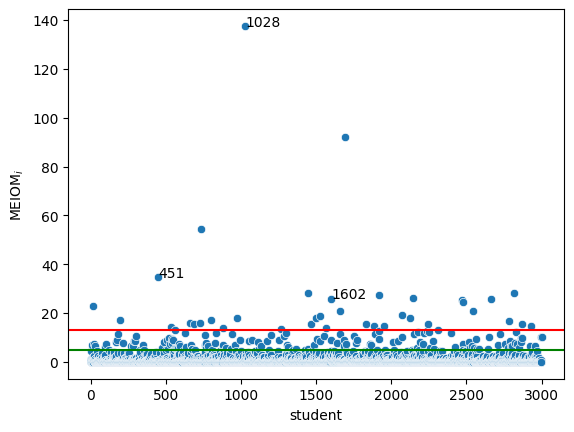

In [33]:
sns.scatterplot(data=iom_i_rf, x='student', y='IOM')
plt.ylabel(r'$\mathrm{MEIOM}_i$')
plt.axhline(y=4.7609, color='green')
plt.axhline(y=12.9904, color='red')
for i in [1028, 451, 1602]:
    plt.annotate(i, (i, iom_i_rf['IOM'][i]))

### School level

In [34]:
results_rf = pd.concat([df, pd.DataFrame(shap_values_rf, columns=['x_phi', 'ses_phi'])], axis=1)

In [35]:
results_rf_sch = pd.concat([results_rf[['ses_phi', 'school']].groupby("school").mean(), pd.Series(model.gamma, name='b_hat')], axis=1)

<Axes: ylabel='Count'>

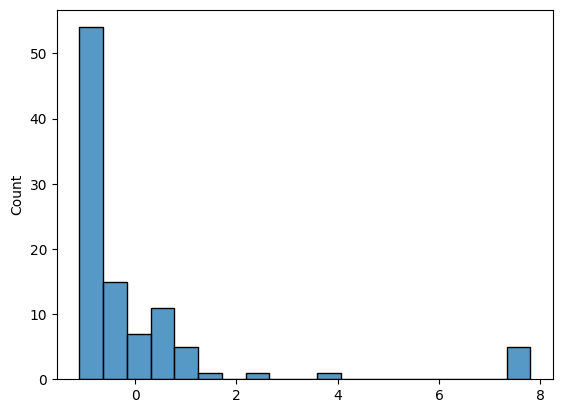

In [36]:
sns.histplot(results_rf_sch['ses_phi'].values)

In [37]:
merf_iom_sch = InfluentialOutlierMetric()

In [38]:
results_iom_sch = merf_iom_sch.find_best_lambda(
    results_rf_sch['ses_phi'].values,
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=9,
    num_bins=32,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:51<00:00,  9.77it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.5228

[1b] Stouffer combined normality p-value
     z = -0.0573
     p = 0.5228
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9969
    CvM p-value: 0.9992
    Q mean:      1.0617  expected approx d=1
    Q max:       7.5143
    min tail p:  0.006121
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:51<00:00,  9.72it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.4885

[1b] Stouffer combined normality p-value
     z = 0.0287
     p = 0.4885
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9956
    CvM p-value: 0.9996
    Q mean:      1.0662  expected approx d=1
    Q max:       7.5730
    min tail p:  0.005925
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.2962

[1b] Stouffer combined normality p-value
     z = 0.5355
     p = 0.2962
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9995
    CvM p-value: 0.9997
    Q mean:      1.0093  expected approx d=1
    Q max:       7.2843
    min tail p:  0.006956
lambda: 0.09697196786440505
cuda


Normalizing flow: 100%|██████████| 500/500 [00:51<00:00,  9.65it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.1415

[1b] Stouffer combined normality p-value
     z = 1.0737
     p = 0.1415
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9633
    CvM p-value: 0.9872
    Q mean:      0.9593  expected approx d=1
    Q max:       7.0654
    min tail p:  0.007859
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:51<00:00,  9.73it/s]

--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.0085

[1b] Stouffer combined normality p-value
     z = 2.3867
     p = 0.008501
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.3172
    CvM p-value: 0.2775
    Q mean:      0.8301  expected approx d=1
    Q max:       6.8206
    min tail p:  0.009011
Final lambda: 0.0970
Mean test distance: 2.9083
Final weights: [np.float32(1.0)]
Final means: [array([0.0534], dtype=float32)]
Final scales: [array([1.0372], dtype=float32)]


<Axes: ylabel='Count'>

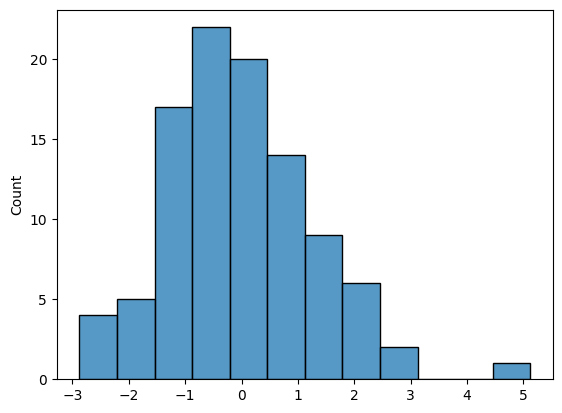

In [39]:
sns.histplot(results_rf_sch['b_hat'].values)

In [40]:
results_iom_sch_resid = merf_iom_sch.find_best_lambda(
    results_rf_sch['b_hat'].values,
    lambdas= np.concatenate([np.array([0]), np.exp(np.linspace(1, 10, 10))]),
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=6,
    num_bins=8,
    torch_seed=42
)


lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:51<00:00,  9.68it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.8339

[1b] Stouffer combined normality p-value
     z = -0.9697
     p = 0.8339
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9981
    CvM p-value: 0.9979
    Q mean:      0.9739  expected approx d=1
    Q max:       7.2565
    min tail p:  0.007064
lambda: 2.718281828459045
cuda


Normalizing flow: 100%|██████████| 500/500 [00:51<00:00,  9.68it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.8008

[1b] Stouffer combined normality p-value
     z = -0.8445
     p = 0.8008
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6833
    CvM p-value: 0.8564
    Q mean:      1.0846  expected approx d=1
    Q max:       7.6048
    min tail p:  0.005821
lambda: 7.38905609893065
cuda


...

--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.5949

[1b] Stouffer combined normality p-value
     z = -0.2403
     p = 0.5949
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5651
    CvM p-value: 0.6054
    Q mean:      1.1668  expected approx d=1
    Q max:       9.8865
    min tail p:  0.001665
lambda: 403.4287934927351
cuda


Normalizing flow: 100%|██████████| 500/500 [00:50<00:00,  9.92it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.3256

[1b] Stouffer combined normality p-value
     z = 0.4521
     p = 0.3256
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5887
    CvM p-value: 0.6417
    Q mean:      1.1831  expected approx d=1
    Q max:       12.4721
    min tail p:  0.0004131
lambda: 1096.6331584284585
cuda


Normalizing flow: 100%|██████████| 500/500 [00:52<00:00,  9.55it/s]


--- Whitened mode-normality diagnostics (n=100, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 100  test: Jarque-Bera  pvalue: 0.0308

[1b] Stouffer combined normality p-value
     z = 1.8696
     p = 0.03077
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5805
    CvM p-value: 0.7151
    Q mean:      1.2202  expected approx d=1
    Q max:       16.7348
    min tail p:  4.299e-05
Final lambda: 403.4288
Mean test distance: 0.0236
Final weights: [np.float32(1.0)]
Final means: [array([0.1329], dtype=float32)]
Final scales: [array([1.1252], dtype=float32)]


In [42]:
IOM_sch = merf_iom_sch.IOM(results_iom_sch, results_iom_sch_resid)

In [43]:
results_rf_sch['IOM'] = IOM_sch
results_rf_sch = results_rf_sch.reset_index().rename({"index":"school"}, axis=1)

In [44]:
results_rf_sch['shap_z'] = results_iom_sch['chi_z']
results_rf_sch['resid_z'] = results_iom_sch_resid['chi_z']

In [45]:
results_rf_sch.sort_values('IOM', ascending=False)

,school,ses_phi,b_hat,IOM,shap_z,resid_z
67,67,7.697476,5.125700,6.525449e+01,5.232021,12.472139
18,18,7.803829,-1.954162,2.039217e+01,7.065422,2.886193
90,90,7.550364,-2.321151,2.008403e+01,4.895541,4.102514
94,94,7.717553,2.003150,1.841031e+01,5.611611,3.280753
75,75,3.875673,-2.351789,1.366833e+01,3.243680,4.213833
...,...,...,...,...,...,...
28,28,-0.597402,0.302004,4.455425e-04,0.004870,0.091484
5,5,-0.658476,1.191870,2.974409e-05,0.000025,1.190556
31,31,-0.701831,-0.187208,2.598269e-05,0.001501,0.017315
61,61,-0.661192,1.841541,1.361755e-05,0.000005,2.781641


In [46]:
sum(results_rf_sch['IOM'] > 12.9904)

5

In [0]:
results_rf_sch.loc[60]

school     60.000000
ses_phi     7.781141
b_hat       0.605412
IOM         2.276929
Name: 60, dtype: float64

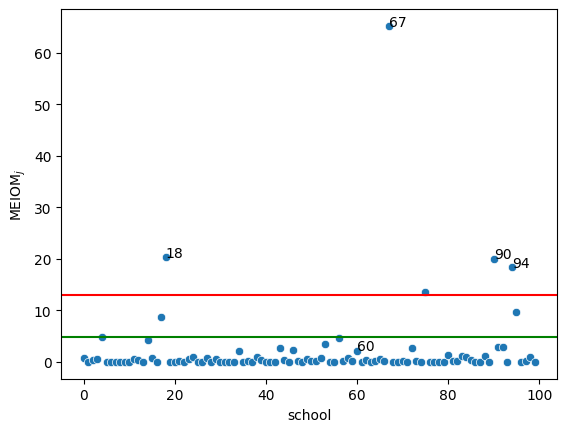

In [47]:
sns.scatterplot(data=results_rf_sch, x='school', y='IOM')
plt.ylabel(r'$\mathrm{MEIOM}_j$')
plt.axhline(y=4.7609, color='green')
plt.axhline(y=12.9904, color='red')
for i in [90, 18, 60, 94, 67]:
    plt.annotate(i, (i, results_rf_sch['IOM'][i]))